## Загрузка библиотек и датасета

В работе используется датасет `train.csv`, содержащий информацию о пассажирах Титаника и их выживаемости.

Для анализа и визуализации используются библиотеки:

- `pandas` — работа с данными
- `matplotlib` и `seaborn` — визуализация
- `plotly` — интерактивные графики

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import plotly.express as px

sns.set(style="whitegrid")

df = pd.read_csv("/Users/eyeoftheigor/Documents/GitHub/train.csv")

df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


## Первичный анализ данных

Ниже можно увидеть размер датасета, типы переменных и основные статистики.

In [2]:
df.shape

(891, 12)

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [4]:
df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


## Визуализация распределений признаков

Рассмотрим распределения следующих переменных:

- `Survived` — выжил пассажир или нет
- `Pclass` — класс пассажира
- `Age` — возраст
- `Sex` — пол
- `Parch` — количество родителей/ детей на борту

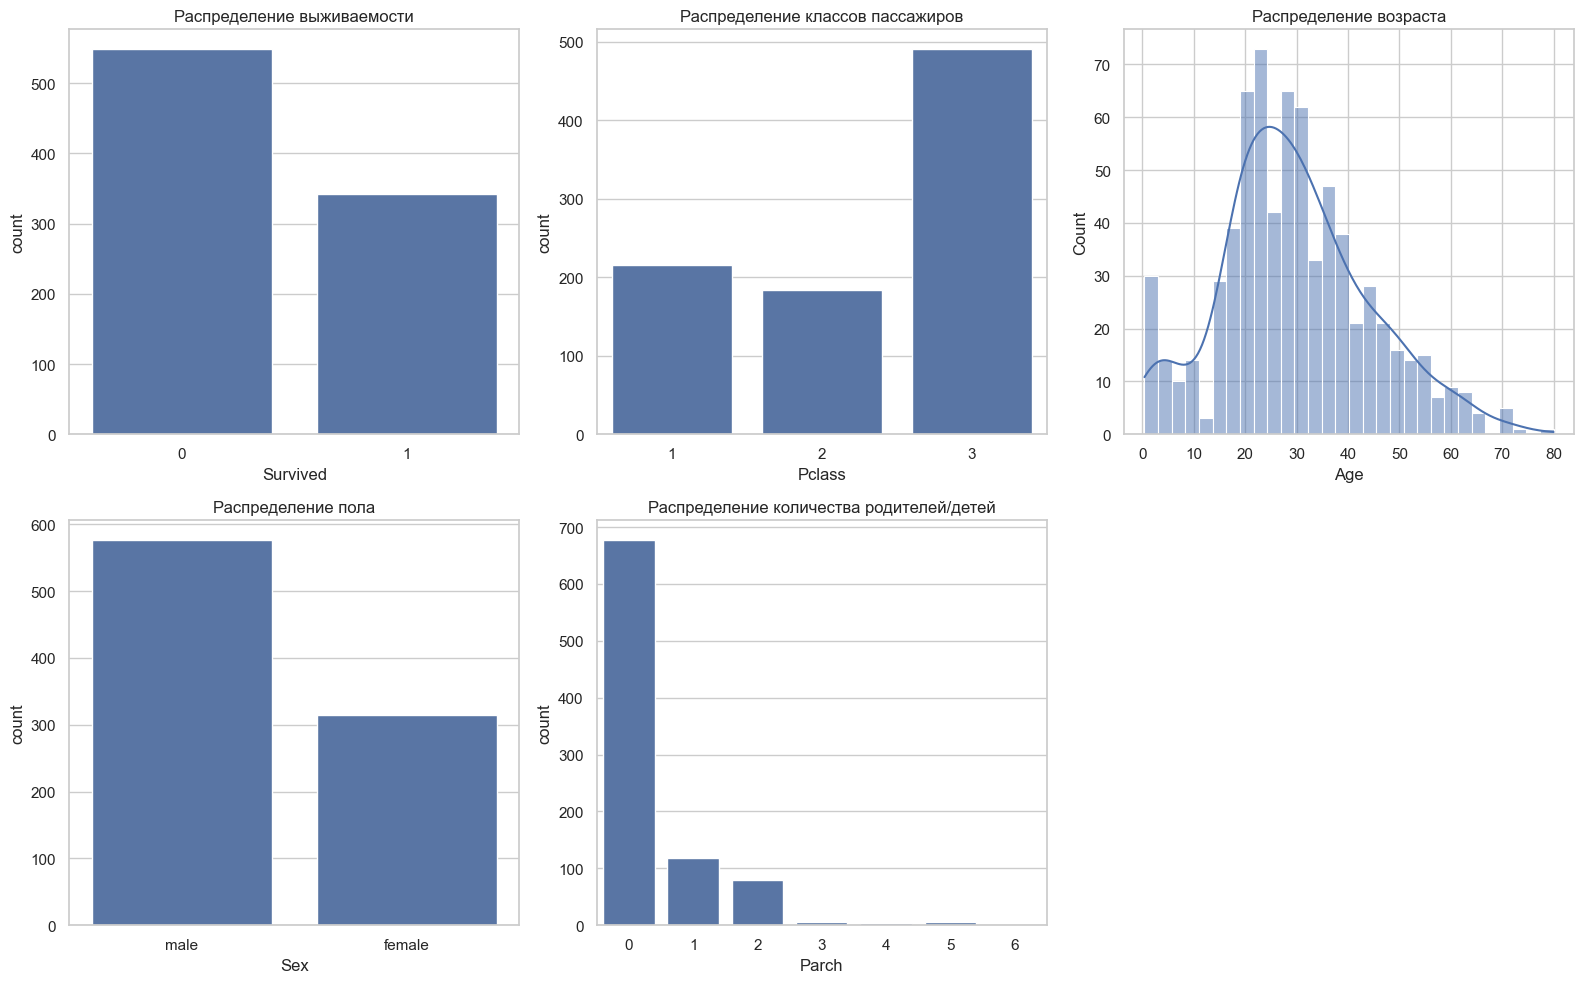

In [5]:
fig, axes = plt.subplots(2, 3, figsize=(16,10))

sns.countplot(data=df, x="Survived", ax=axes[0,0])
axes[0,0].set_title("Распределение выживаемости")

sns.countplot(data=df, x="Pclass", ax=axes[0,1])
axes[0,1].set_title("Распределение классов пассажиров")

sns.histplot(df["Age"], bins=30, kde=True, ax=axes[0,2])
axes[0,2].set_title("Распределение возраста")

sns.countplot(data=df, x="Sex", ax=axes[1,0])
axes[1,0].set_title("Распределение пола")

sns.countplot(data=df, x="Parch", ax=axes[1,1])
axes[1,1].set_title("Распределение количества родителей/детей")

axes[1,2].axis("off")

plt.tight_layout()
plt.show()

## Boxplot распределения возраста

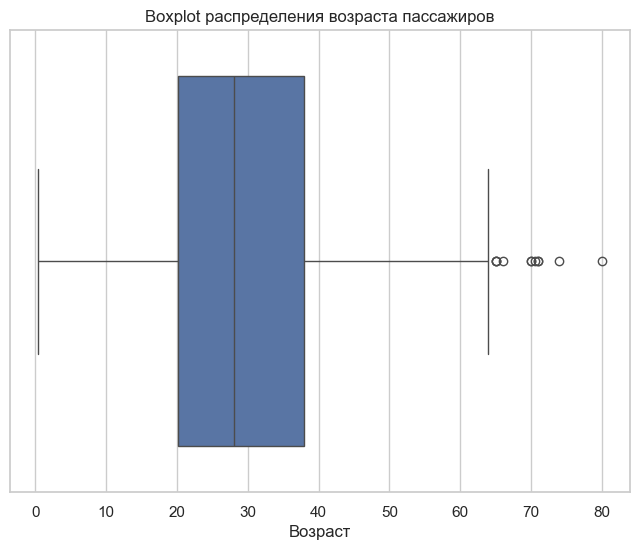

In [6]:
plt.figure(figsize=(8,6))

sns.boxplot(x=df["Age"])

plt.title("Boxplot распределения возраста пассажиров")
plt.xlabel("Возраст")

plt.show()

## Интерпретация boxplot

По графику можно сделать следующие выводы:

1. Медианный возраст пассажиров находится примерно около **28–30 лет**.
2. Основная часть пассажиров находится в диапазоне примерно **20–40 лет**.
3. Наблюдаются **скачки** в сторону больших возрастов (70–80 лет).
4. На борту также есть небольшое количество детей.

Таким образом, возрастная структура пассажиров Титаника была сосредоточена преимущественно среди людей молодого и среднего возрастов.

## Круговые диаграммы

Теперь построим круговые диаграммы для визуальной демонстрации:

- выживаемости пассажиров
- распределения пассажиров по классам

Доли подписаны в процентах.

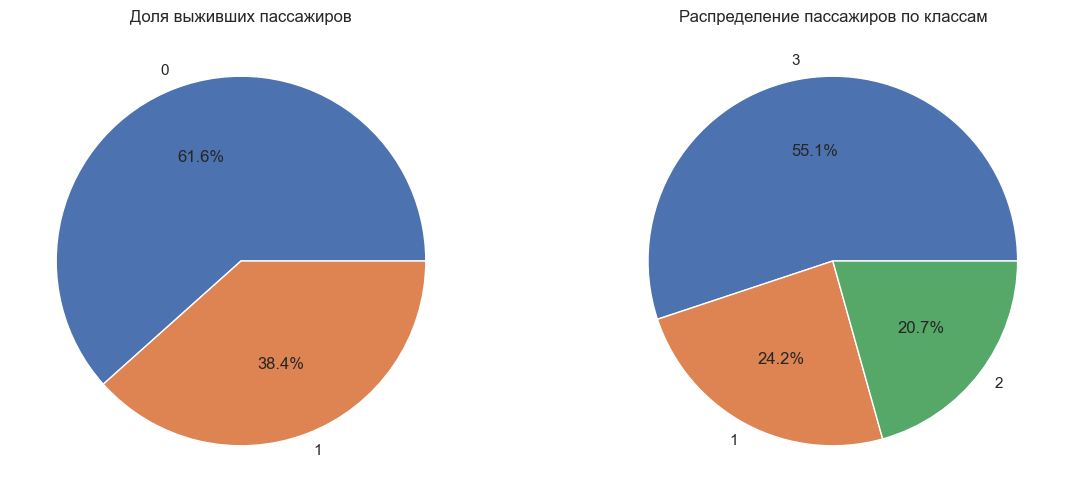

In [7]:
fig, axes = plt.subplots(1,2, figsize=(14,6))

df["Survived"].value_counts().plot.pie(
    autopct="%1.1f%%",
    ax=axes[0],
    title="Доля выживших пассажиров",
    ylabel=""
)

df["Pclass"].value_counts().plot.pie(
    autopct="%1.1f%%",
    ax=axes[1],
    title="Распределение пассажиров по классам",
    ylabel=""
)

plt.show()

## Pairplot числовых переменных

Pairplot позволяет визуально изучить взаимосвязи между числовыми признаками датасета.

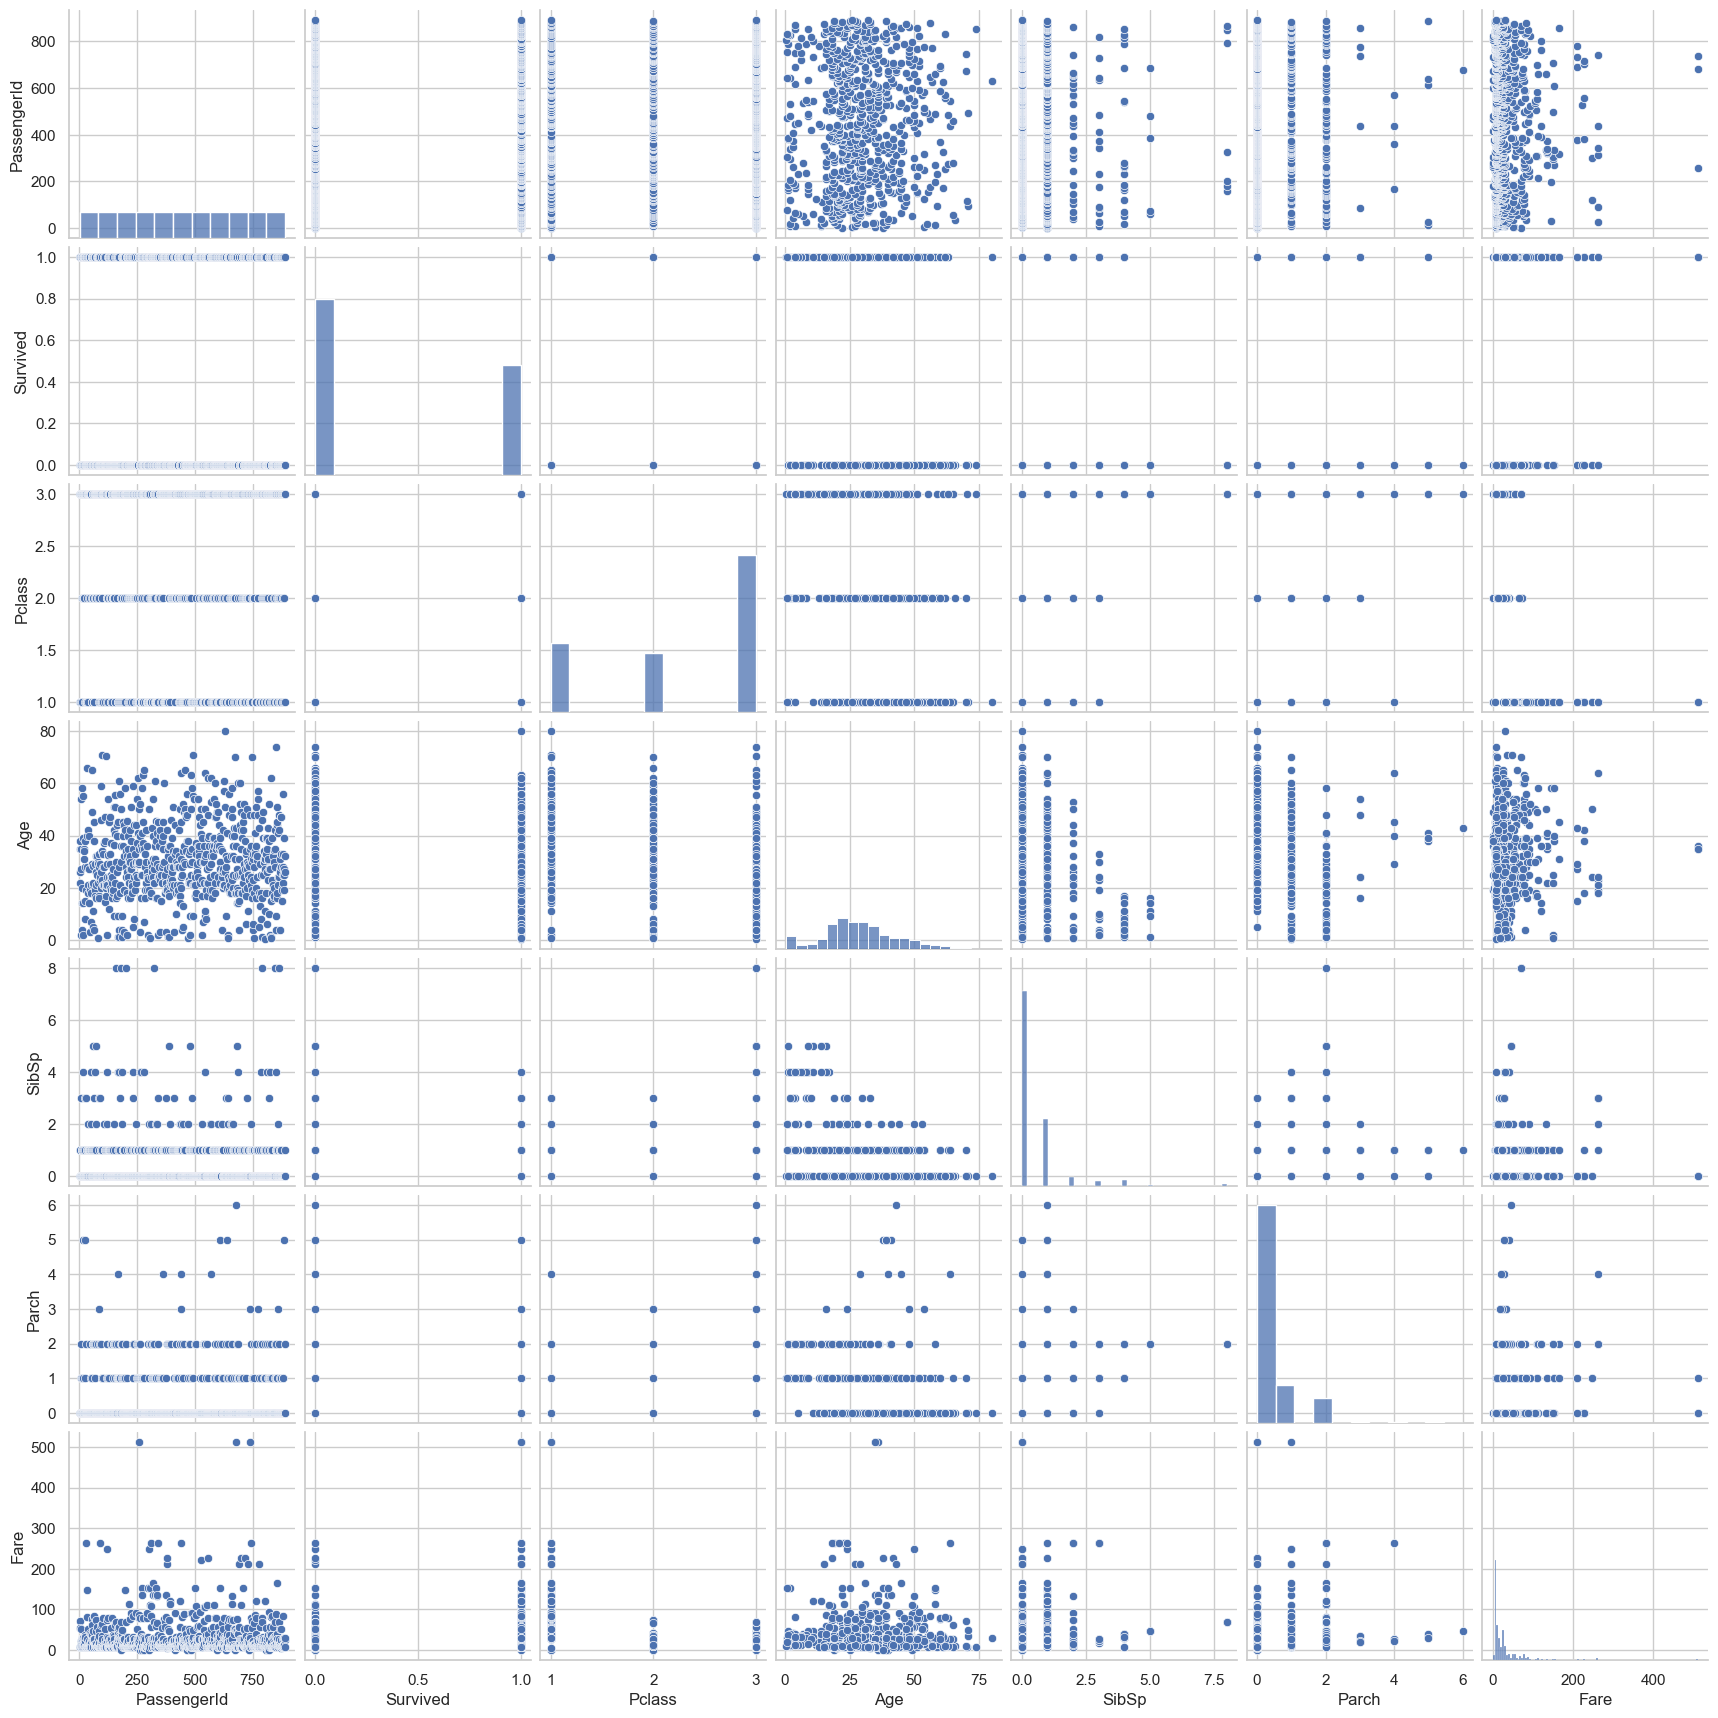

In [8]:
numeric_df = df.select_dtypes(include=["int64", "float64"])

sns.pairplot(numeric_df)

plt.show()

## Violin plot возраста в зависимости от пола

Violin plot показывает:

- форму распределения
- плотность данных
- медиану и разброс

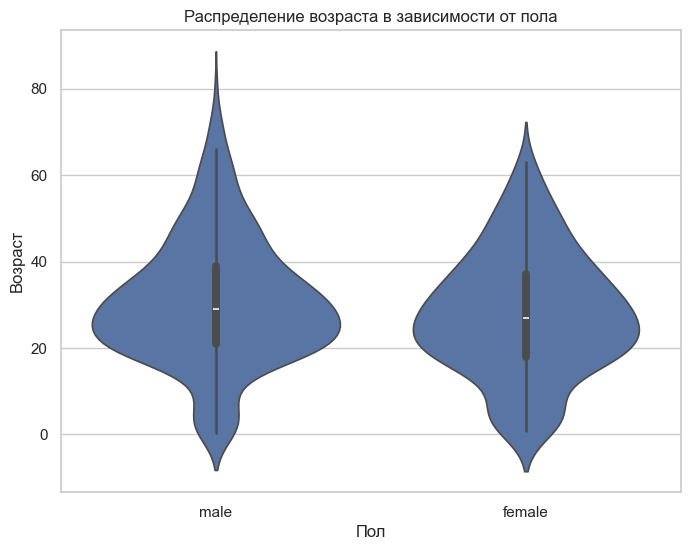

In [9]:
plt.figure(figsize=(8,6))

sns.violinplot(data=df, x="Sex", y="Age")

plt.title("Распределение возраста в зависимости от пола")
plt.xlabel("Пол")
plt.ylabel("Возраст")

plt.show()

## Корреляционная матрица числовых признаков

Корреляционная матрица позволяет оценить линейную зависимость между переменными.

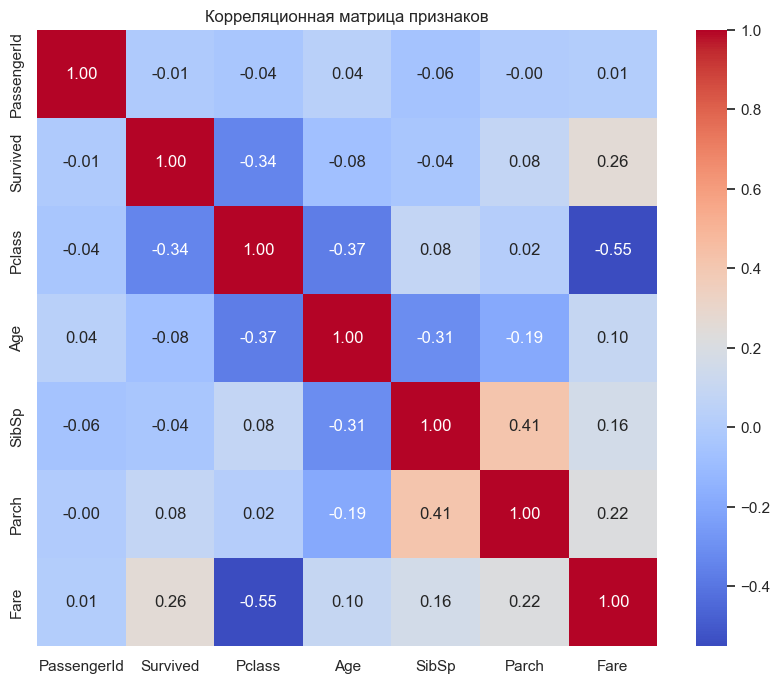

In [10]:
plt.figure(figsize=(10,8))

corr = numeric_df.corr()

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Корреляционная матрица признаков")

plt.show()

## Интерактивная диаграмма Sunburst

Структура:

1 уровень — класс пассажира  
2 уровень — пол пассажира внутри класса

In [11]:
sunburst_data = (
    df.groupby(["Pclass", "Sex"])
    .size()
    .reset_index(name="count")
)

fig = px.sunburst(
    sunburst_data,
    path=["Pclass", "Sex"],
    values="count",
    title="Структура пассажиров по классу и полу"
)

fig.show()

## Функция извлечения имени после титула

В колонке `Name` структура записи:


In [12]:
import re

def extract_first_name(name):

    name_part = name.split(".")[1].strip()

    match = re.search(r"\((.*?)\)", name_part)
    if match:
        name_part = match.group(1)

    first_name = name_part.split()[0]

    return first_name

## Пример применения

In [13]:
df["FirstName"] = df["Name"].apply(extract_first_name)

df[["Name","FirstName"]].head()

,Name,FirstName
0,"Braund, Mr. Owen Harris",Owen
1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",Florence
2,"Heikkinen, Miss. Laina",Laina
3,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",Lily
4,"Allen, Mr. William Henry",William
